<a href="https://colab.research.google.com/github/jahnavimala/Predictive-Modeling-Using-Machine-Learning/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ==========================================
# HEART DISEASE PREDICTION USING ML
# ==========================================

# Install dependencies:
# pip install kagglehub[pandas-datasets]
# pip install pandas numpy matplotlib seaborn scikit-learn

# ==========================================
# STEP 1: Import Libraries
# ==========================================

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [6]:
# ==========================================
# STEP 2: Load Dataset from Kaggle
# ==========================================

# Provide the specific file name within the dataset
file_path = "heart.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "johnsmith88/heart-disease-dataset",
    file_path
)

print("\n========== FIRST 5 RECORDS ==========")
print(df.head())

/tmp/ipykernel_893/451855642.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-disease-dataset' dataset.

========== FIRST 5 RECORDS ==========
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [7]:
# ==========================================
# STEP 3: Basic Exploration
# ==========================================

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())


========== DATASET SHAPE ==========
(1025, 14)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

========== STATISTICAL SUMMARY ==========
               age          sex           cp     trestbps        chol  \
count  1025

In [8]:
# ==========================================
# STEP 4: Data Cleaning
# ==========================================

# Missing values
print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# Fill missing values if any
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicates
print("\n========== DUPLICATES ==========")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)


========== MISSING VALUES ==========
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

========== DUPLICATES ==========
723


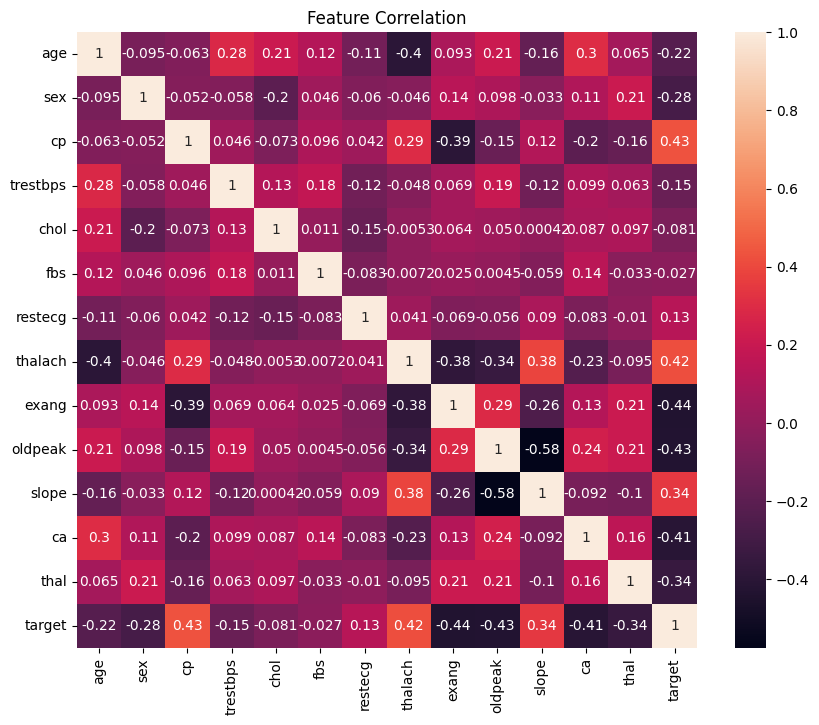

In [9]:
# ==========================================
# STEP 5: Correlation Analysis
# ==========================================

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [10]:
# ==========================================
# STEP 6: Split Features and Target
# ==========================================

# Target column = target
X = df.drop("target", axis=1)
y = df["target"]

In [11]:
# ==========================================
# STEP 7: Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# ==========================================
# STEP 8: Train Models
# ==========================================

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
# ==========================================
# STEP 9: Predictions
# ==========================================

dt_predictions = dt_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

In [14]:
# ==========================================
# STEP 10: Model Evaluation
# ==========================================

# Decision Tree Accuracy
dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

# Random Forest Accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("\n========== MODEL ACCURACY ==========")
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)


========== MODEL ACCURACY ==========
Decision Tree Accuracy: 0.7377049180327869
Random Forest Accuracy: 0.8360655737704918


In [15]:
# ==========================================
# STEP 11: Classification Report
# ==========================================

print("\n========== RANDOM FOREST REPORT ==========")
print(
    classification_report(
        y_test,
        rf_predictions
    )
)


========== RANDOM FOREST REPORT ==========
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61




========== CONFUSION MATRIX ==========
[[25  7]
 [ 3 26]]


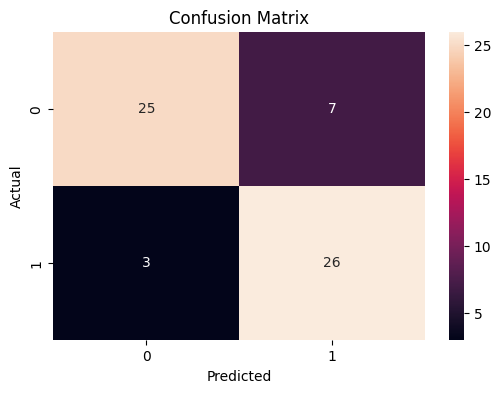

In [16]:
# ==========================================
# STEP 12: Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    rf_predictions
)

print("\n========== CONFUSION MATRIX ==========")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

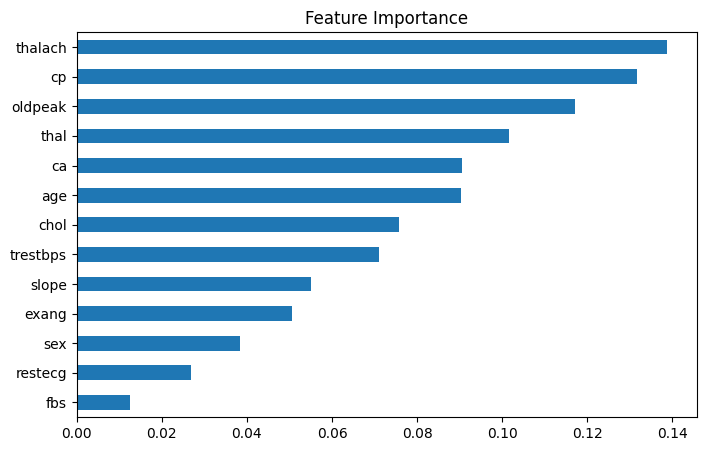

In [17]:
# ==========================================
# STEP 13: Feature Importance
# ==========================================

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title("Feature Importance")
plt.show()

In [18]:
# ==========================================
# STEP 14: Final Insights
# ==========================================

print("\n========== PROJECT INSIGHTS ==========")
print("1. Random Forest usually performs better.")
print("2. Important health indicators affect predictions.")
print("3. Confusion matrix shows classification quality.")
print("4. Feature importance shows influential factors.")


========== PROJECT INSIGHTS ==========
1. Random Forest usually performs better.
2. Important health indicators affect predictions.
3. Confusion matrix shows classification quality.
4. Feature importance shows influential factors.
